# 와인 품질 예측을 위한 고급 기계학습 분석 전략 및 노트북 아키텍처

## 1. 서론: 데이터 과학과 양조학의 융합적 접근

본 노트북은 `wine_data_homework.csv` 데이터셋을 활용하여 와인 품질(Quality)을 예측하는 기계학습 모델의 성능을 극대화하기 위한 전문가 수준의 분석 파이프라인입니다.

**핵심 목표:**
1. **도메인 지식 기반 특성 공학 (Feature Engineering):** 단순 통계가 아닌 양조학적 원리에 기반한 파생 변수 생성
2. **강건한 전처리 (Robust Preprocessing):** IQR 및 통계적 기법을 활용한 이상치 제거
3. **MLOps 통합:** MLflow를 활용한 실험 추적 및 모델 버전 관리
4. **설명 가능한 AI (XAI):** SHAP 값을 활용한 블랙박스 모델의 해석

---

In [1]:
# [Cell 1] 환경 설정 및 라이브러리 임포트

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 머신러닝 라이브러리
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# MLOps 및 XAI
import mlflow
import mlflow.sklearn
import shap

# 시각화 설정 (한글 폰트 및 스타일)
import platform
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)
sns.set_style("whitegrid")

# MLflow 실험 설정 (로컬 환경 저장 예시)
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Wine_Quality_Prediction_Expert")

print("Environment Setup Complete. MLflow Tracking URI set to ./mlruns")

Environment Setup Complete. MLflow Tracking URI set to ./mlruns


c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\junkim\MyProjects\mlflow_wine\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


## 2. 데이터셋 특성 분석 및 기초 통계

데이터의 물리화학적 의미를 파악하고, 기술 통계량을 통해 분포의 개형과 잠재적 이상치를 1차적으로 진단합니다.

In [2]:
# [Cell 2] 데이터 로드 및 기초 통계 분석

try:
    df = pd.read_csv('wine_data_homework.csv')
    print(f"Data Loaded Successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'wine_data_homework.csv' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    # 더미 데이터 생성 (테스트용)
    # df = pd.DataFrame(...)

# 데이터 정보 및 결측치 확인
display(df.info())
display(df.describe().T)

# 인덱스 제거거
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    # 기본 통계 정보
print("\n=== 기본 통계 정보 ===")
df.describe()

# 결측치 확인
missing_values = df.isnull().sum()
print("\n[Missing Values]\n", missing_values[missing_values > 0])

Data Loaded Successfully. Shape: (4001, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4001 non-null   int64  
 1   fixed acidity         4001 non-null   float64
 2   volatile acidity      4001 non-null   float64
 3   citric acid           4001 non-null   float64
 4   residual sugar        4001 non-null   float64
 5   chlorides             4001 non-null   float64
 6   free sulfur dioxide   4001 non-null   float64
 7   total sulfur dioxide  4001 non-null   float64
 8   density               4001 non-null   float64
 9   pH                    4001 non-null   float64
 10  sulphates             4001 non-null   float64
 11  alcohol               4001 non-null   float64
 12  quality               4001 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 406.5 KB


None

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,4001.0,2000.000000,1155.133542,0.00000,1000.00000,2000.0000,3000.00000,4000.00000
fixed acidity,4001.0,6.957073,0.844565,4.20000,6.40000,6.9000,7.40000,14.20000
volatile acidity,4001.0,0.275809,0.100173,0.08000,0.21000,0.2600,0.32000,1.00500
citric acid,4001.0,0.341135,0.122555,0.00000,0.27000,0.3200,0.40000,1.66000
residual sugar,4001.0,6.363922,5.091003,0.60000,1.70000,5.2000,9.80000,65.80000
chlorides,4001.0,0.045632,0.021958,0.00900,0.03600,0.0430,0.05000,0.34600
free sulfur dioxide,4001.0,35.571357,16.909183,2.00000,24.00000,34.0000,46.00000,146.50000
total sulfur dioxide,4001.0,140.483504,43.260052,9.00000,109.00000,137.0000,170.00000,366.50000
density,4001.0,0.994188,0.002992,0.98713,0.99188,0.9939,0.99625,1.03898
pH,4001.0,3.191922,0.152905,2.72000,3.09000,3.1800,3.29000,3.82000



=== 기본 통계 정보 ===

[Missing Values]
 Series([], dtype: int64)


## 3. 탐색적 데이터 분석 (EDA) 고도화

단순 히스토그램을 넘어 정규성 검정(Shapiro-Wilk)을 수행하여 변수 변환의 필요성을 과학적으로 판단합니다.

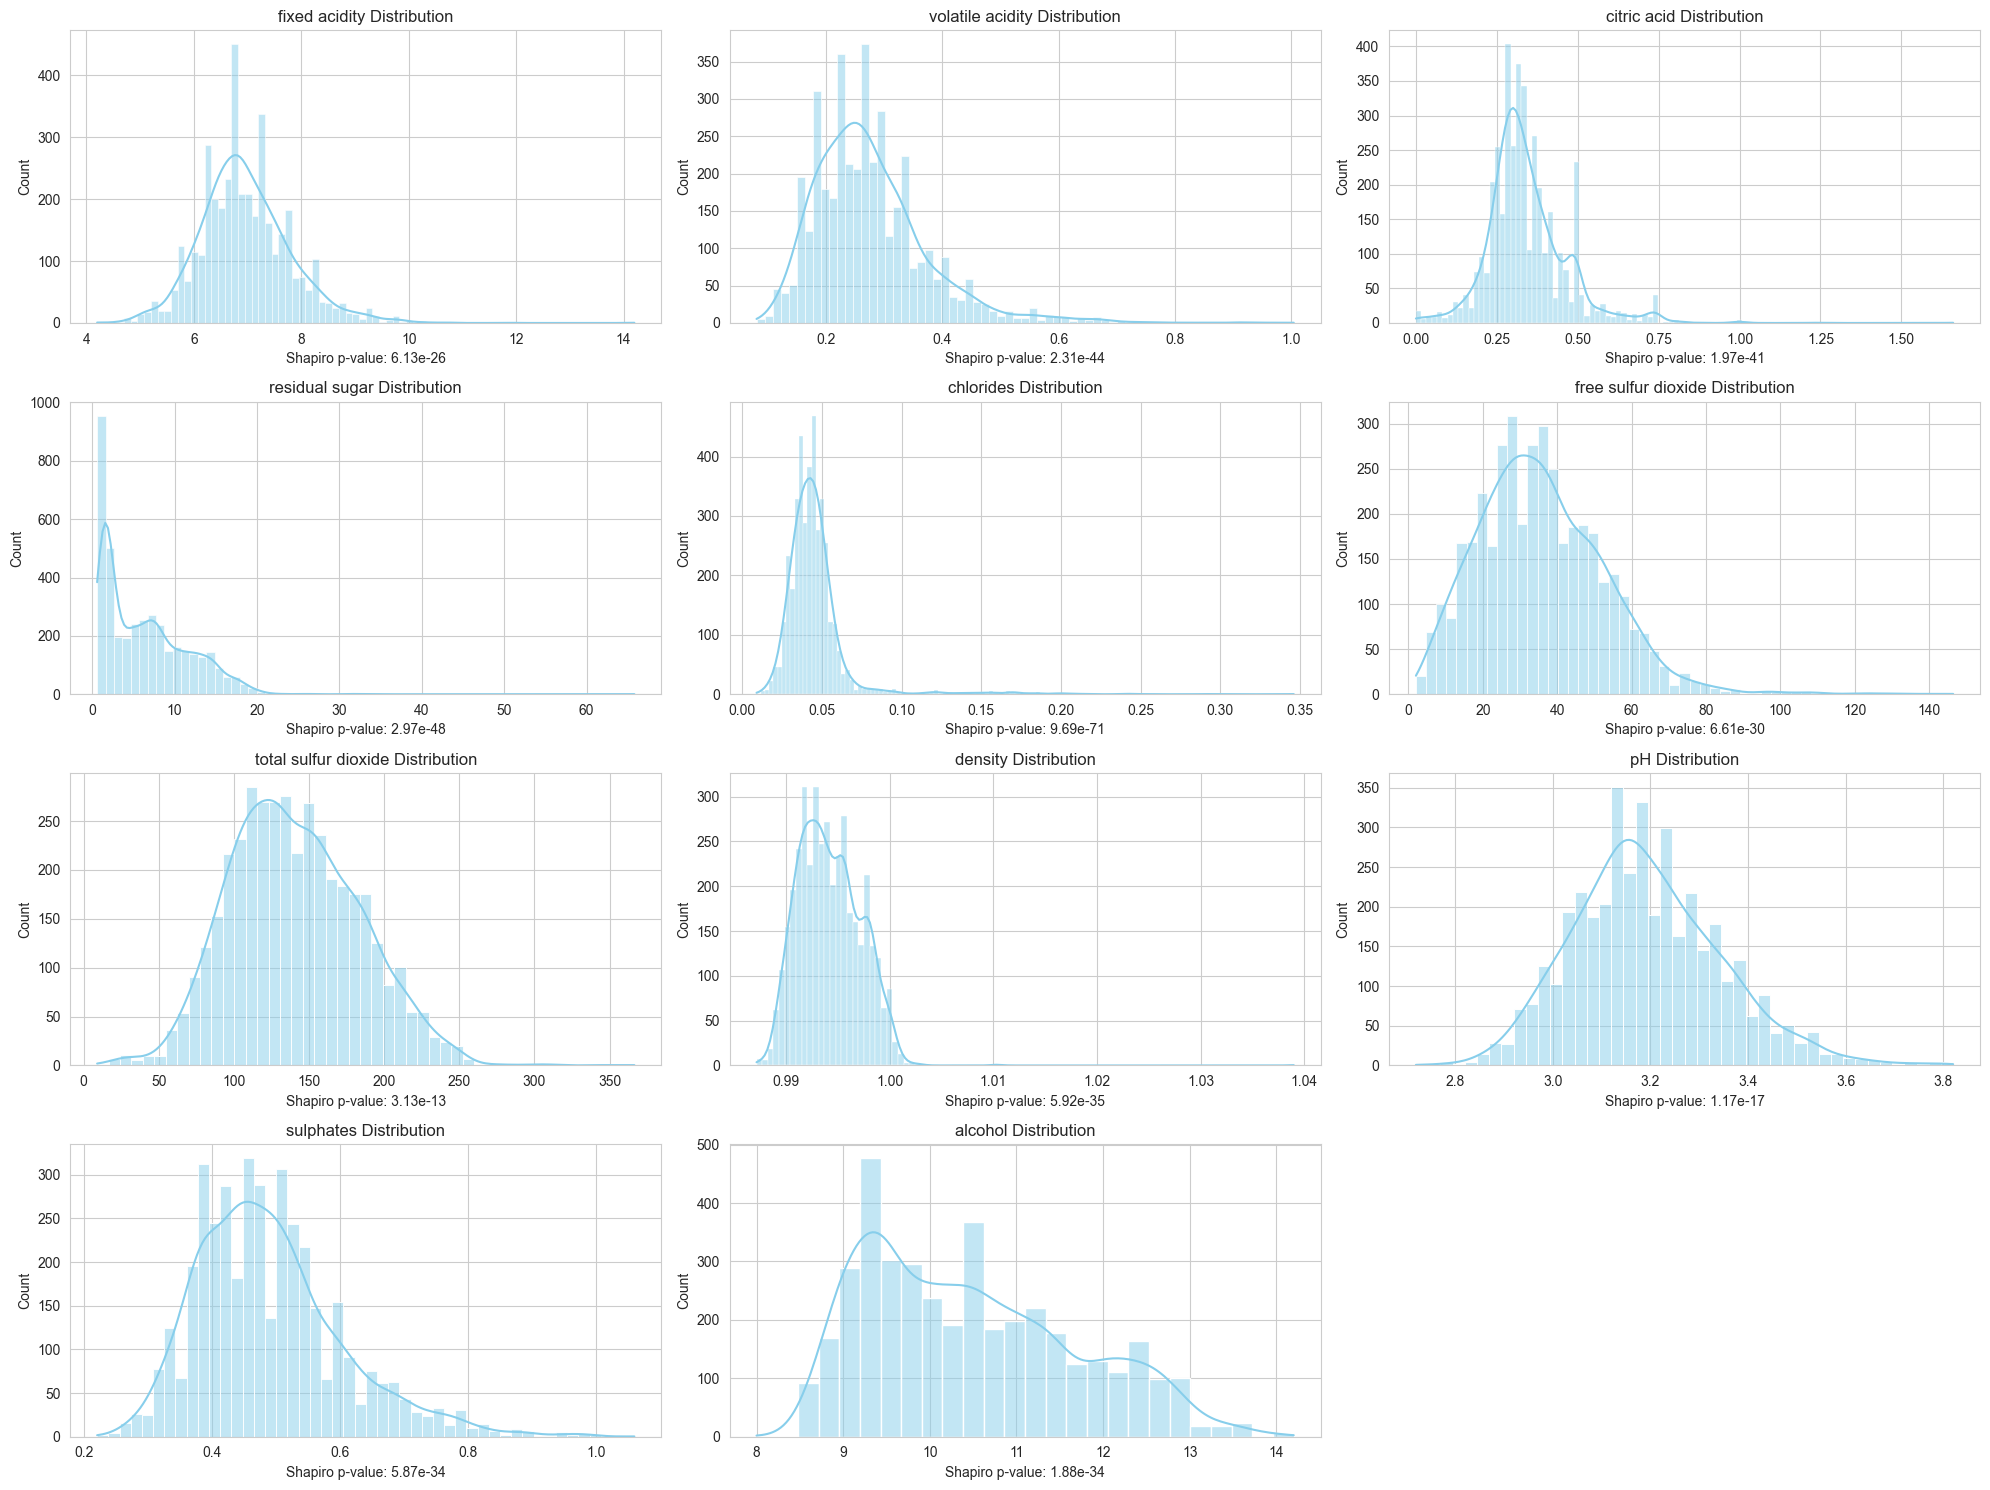

In [3]:
# [Cell 3] EDA 1단계: 단변량 분포 시각화 및 정규성 검정

features = df.columns.drop('quality')
plt.figure(figsize=(20, 15))

for i, feature in enumerate(features):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[feature], kde=True, color='skyblue')
    plt.title(f'{feature} Distribution')
    
    # 정규성 검정 (샘플 수가 많으므로 p-value 해석에 유의, 통계량 확인용)
    if len(df) < 5000:
        stat, p = stats.shapiro(df[feature])
        plt.xlabel(f'Shapiro p-value: {p:.2e}')

plt.tight_layout()
plt.show()

### 이변량 분석: 다중공선성 진단
변수 간의 상관관계를 분석하여 `Density`와 `Alcohol` 처럼 구조적으로 얽혀있는 변수(Collinearity)를 식별합니다.

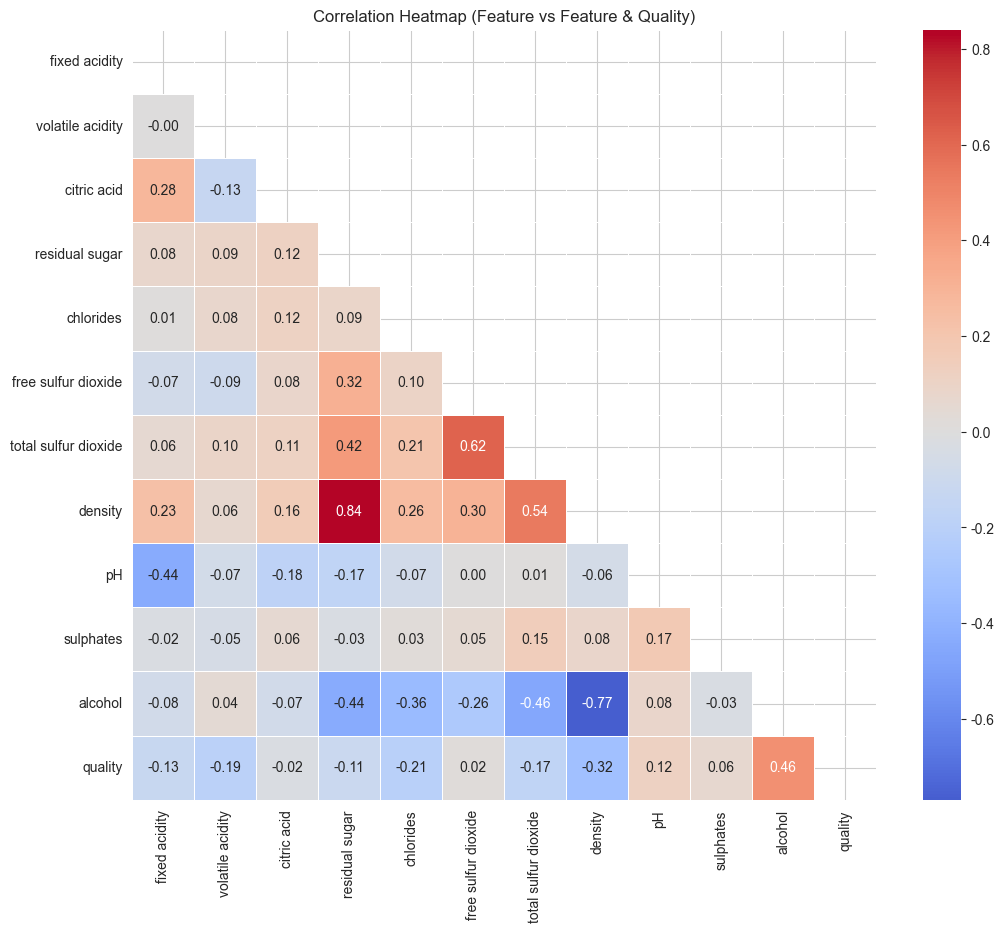

Top Correlation with Quality:
quality                 1.000000
alcohol                 0.455195
pH                      0.119152
sulphates               0.064406
free sulfur dioxide     0.022081
citric acid            -0.024022
residual sugar         -0.113203
fixed acidity          -0.126006
total sulfur dioxide   -0.170639
volatile acidity       -0.191424
chlorides              -0.209557
density                -0.324650
Name: quality, dtype: float64


In [4]:
# [Cell 4] EDA 2단계: 상관관계 히트맵

plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (Feature vs Feature & Quality)')
plt.show()

# Quality와 가장 상관관계가 높은 변수 출력
print("Top Correlation with Quality:")
print(corr_matrix['quality'].sort_values(ascending=False))

### 품질 등급별 특성 비교
품질(Quality) 등급에 따라 각 화학 성분이 어떻게 분포하는지 Boxplot을 통해 시각적으로 검증합니다.

C:\Users\junkim\AppData\Local\Temp\ipykernel_24468\2414088621.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df, palette='viridis')
C:\Users\junkim\AppData\Local\Temp\ipykernel_24468\2414088621.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df, palette='viridis')
C:\Users\junkim\AppData\Local\Temp\ipykernel_24468\2414088621.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=feature, data=df, palette='viridis')
C:\Users\junkim\AppData\Local\Temp\ipykernel_2446

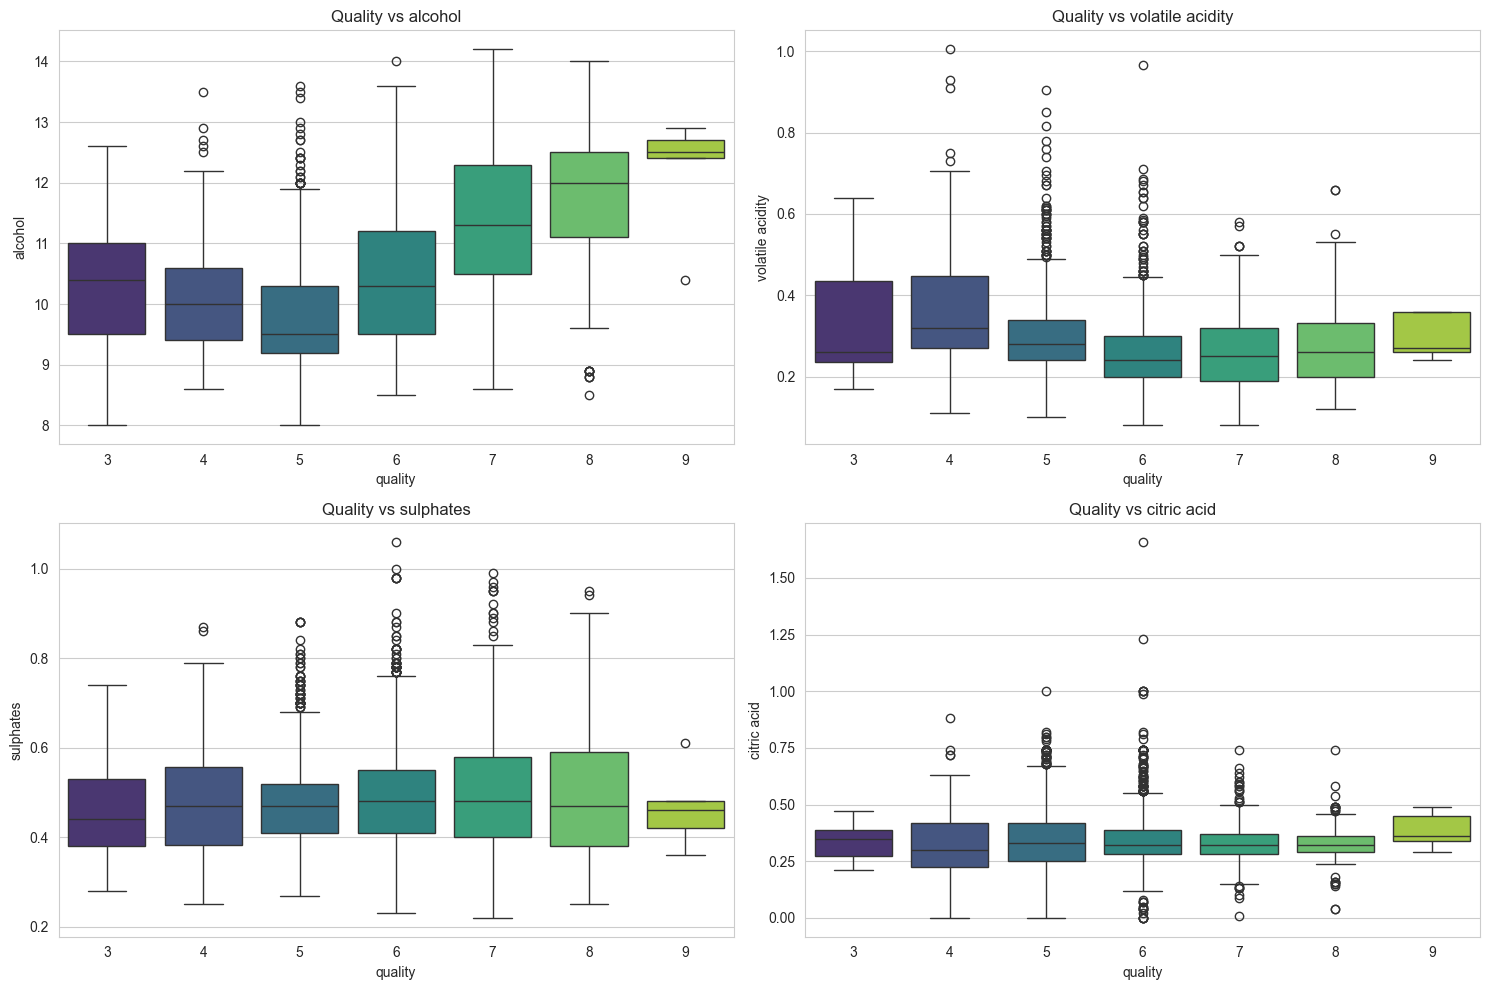

In [5]:
# [Cell 5] EDA 3단계: 품질 등급별 특성 비교 (Boxplot)

selected_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='quality', y=feature, data=df, palette='viridis')
    plt.title(f'Quality vs {feature}')

plt.tight_layout()
plt.show()

## 4. 데이터 전처리: 이상치(Outlier) 제거

IQR(Interquartile Range) 방식을 사용하여 통계적으로 비정상적인 관측치를 제거합니다. 이는 모델의 일반화 성능을 높이는 핵심 단계입니다.

In [6]:
# [Cell 6] 전처리: 이상치 제거 및 데이터 정제

def remove_outliers_iqr(data, columns, multiplier=1.5):
    df_clean = data.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        # 이상치 필터링
        condition = (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
        df_clean = df_clean[condition]
        
    return df_clean

# 품질(quality)은 종속변수이므로 이상치 제거 대상에서 제외할 수도 있으나, 
# 여기서는 독립변수(X)들에 대해서만 이상치를 제거합니다.
outlier_target_cols = ['residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'chlorides']

original_shape = df.shape
df_cleaned = remove_outliers_iqr(df, outlier_target_cols, multiplier=1.5)
new_shape = df_cleaned.shape

print(f"Original Data Shape: {original_shape}")
print(f"Cleaned Data Shape: {new_shape}")
print(f"Removed Samples: {original_shape[0] - new_shape[0]} ({ (original_shape[0] - new_shape[0])/original_shape[0]*100 :.2f}%)")

Original Data Shape: (4001, 12)
Cleaned Data Shape: (3762, 12)
Removed Samples: 239 (5.97%)


## 5. 특성 공학 (Feature Engineering): 도메인 지식의 결합

단순 수치 계산이 아닌, 와인 양조학(Enology) 지식을 바탕으로 유의미한 파생 변수를 생성합니다.

In [7]:
# [Cell 7] 고급 특성 공학 (Feature Engineering)

# 1. Total Acidity: 와인의 전체적인 구조감 (Fixed + Volatile)
df_cleaned['total_acidity'] = df_cleaned['fixed acidity'] + df_cleaned['volatile acidity']

# 2. Free Sulfur Dioxide Ratio: 방부제의 효율성 (Free / Total)
# 분모가 0일 경우를 대비해 예외처리 혹은 0 제거가 필요하지만, 데이터 특성상 Total SO2가 0인 경우는 드뭄
df_cleaned['free_sulfur_ratio'] = df_cleaned['free sulfur dioxide'] / (df_cleaned['total sulfur dioxide'] + 1e-5)

# 3. Alcohol to Sugar Ratio: 발효 완전성 지표 (Alcohol / Sugar)
df_cleaned['alcohol_sugar_ratio'] = df_cleaned['alcohol'] / (df_cleaned['residual sugar'] + 1e-5)

# 4. Bound Sulfur Dioxide: 결합 이산화황 (Total - Free), 품질에 부정적 영향 가능성
df_cleaned['bound_sulfur_dioxide'] = df_cleaned['total sulfur dioxide'] - df_cleaned['free sulfur dioxide']

print("Feature Engineering Complete.")
display(df_cleaned[['total_acidity', 'free_sulfur_ratio', 'alcohol_sugar_ratio', 'bound_sulfur_dioxide']].head())

Feature Engineering Complete.


,total_acidity,free_sulfur_ratio,alcohol_sugar_ratio,bound_sulfur_dioxide
0,7.27,0.264706,0.425121,125.0
1,6.60,0.106061,5.937463,118.0
2,8.38,0.309278,1.463766,67.0
3,7.43,0.252688,1.164705,139.0
4,7.43,0.252688,1.164705,139.0


## 6. 데이터 분할 및 스케일링

모델 학습을 위해 데이터를 분할하고, 변수 간 스케일 차이를 없애기 위해 표준화(Standardization)를 수행합니다.

In [8]:
# [Cell 8] 데이터 분할 및 스케일링

# 타겟 및 피처 설정
X = df_cleaned.drop('quality', axis=1)
y = df_cleaned['quality']

# Train/Test Split (75:25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Scaling (StandardScaler)
scaler = StandardScaler()

# Data Leakage 방지를 위해 Train 데이터로만 fit 수행
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일링 된 데이터를 DataFrame으로 변환 (컬럼명 유지)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Data Split and Scaling Complete.")

Data Split and Scaling Complete.


## 7. 모델링 및 MLflow 실험 추적

ElasticNet, Random Forest, XGBoost 세 가지 모델을 학습하고 MLflow를 통해 성능을 기록합니다.

In [9]:
# [Cell 9] 모델링 및 MLflow 실험 추적

def train_and_log_model(model, model_name, X_train, y_train, X_test, y_test):
    with mlflow.start_run(run_name=model_name):
        # 모델 학습
        model.fit(X_train, y_train)
        
        # 예측
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        # 평가 지표 계산
        rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        r2 = r2_score(y_test, test_pred)
        
        # MLflow 로깅
        mlflow.log_param("model_type", model_name)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)
        
        # 모델 저장
        mlflow.sklearn.log_model(model, model_name)
        
        print(f"[{model_name}] RMSE: {rmse:.4f}, R2: {r2:.4f}")
        return model

# 1. ElasticNet (선형 모델, 규제 적용)
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
trained_enet = train_and_log_model(enet, "ElasticNet", X_train_scaled, y_train, X_test_scaled, y_test)

# 2. Random Forest (앙상블, 배깅)
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
trained_rf = train_and_log_model(rf, "RandomForest", X_train_scaled, y_train, X_test_scaled, y_test)

# 3. XGBoost (앙상블, 부스팅)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
trained_xgb = train_and_log_model(xgb, "XGBoost", X_train_scaled, y_train, X_test_scaled, y_test)

2025/11/28 00:47:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/28 00:47:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[ElasticNet] RMSE: 0.7726, R2: 0.2662


2025/11/28 00:47:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/28 00:47:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/28 00:47:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[RandomForest] RMSE: 0.6388, R2: 0.4983


2025/11/28 00:47:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[XGBoost] RMSE: 0.6791, R2: 0.4331


## 8. 결과 심층 분석 및 시각화 (XAI)

모델의 예측 성능을 시각화하고, SHAP 값을 통해 변수 중요도를 해석합니다.

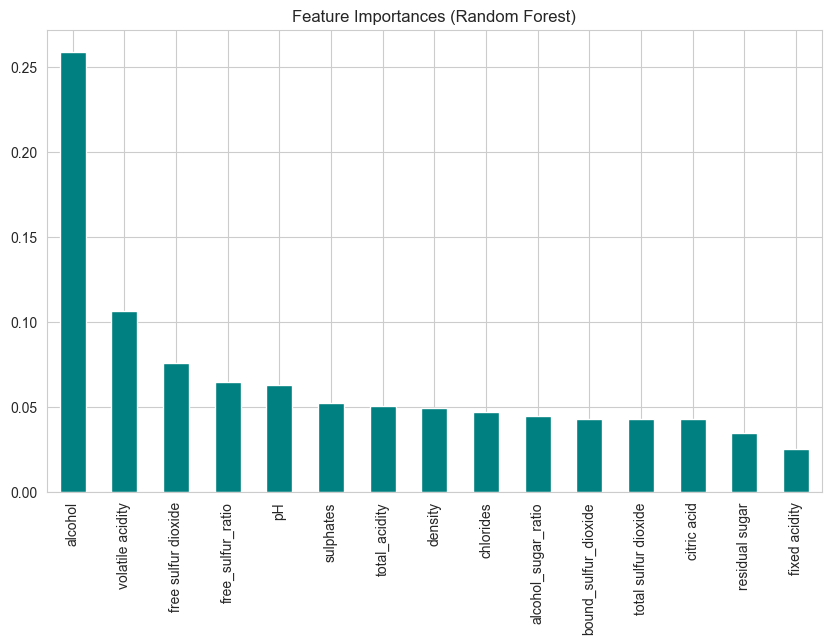

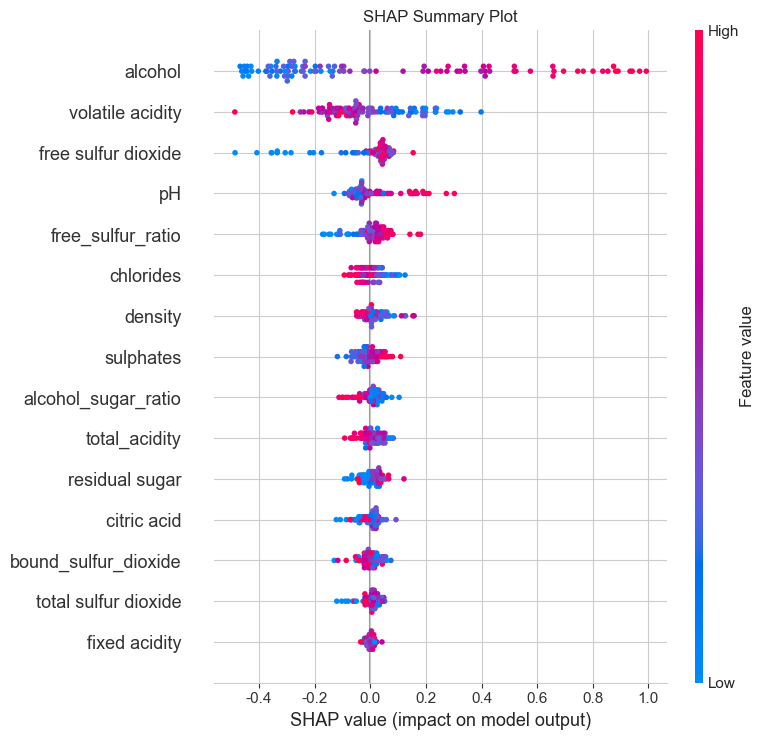

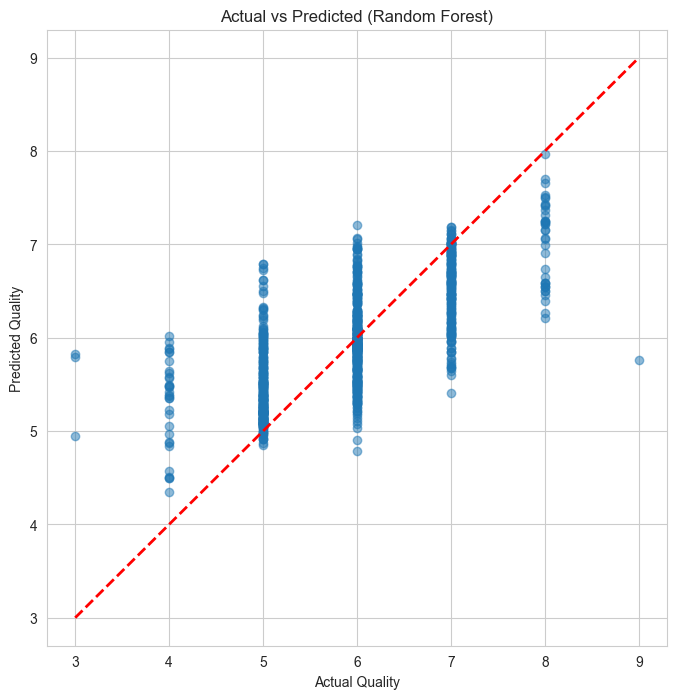

In [10]:
# [Cell 10] 결과 심층 분석 및 시각화

# Random Forest 모델 기준 Feature Importance
feature_importances = pd.Series(trained_rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Feature Importances (Random Forest)')
plt.show()

# SHAP Value 분석 (모델 해석)
try:
    explainer = shap.TreeExplainer(trained_rf)
    # 계산 비용 절감을 위해 일부 샘플만 사용
    shap_values = explainer.shap_values(X_test_scaled.iloc[:100, :])
    
    plt.figure()
    plt.title("SHAP Summary Plot")
    shap.summary_plot(shap_values, X_test_scaled.iloc[:100, :], show=False)
    plt.show()
except Exception as e:
    print(f"SHAP analysis error: {e}")

# 실제값 vs 예측값 시각화
final_pred = trained_rf.predict(X_test_scaled)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, final_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Actual vs Predicted (Random Forest)')
plt.show()